# Model Comparison

Loads each model's saved predictions (no retraining) and puts RF, XGBoost, and the Neural Network side by side on the metrics that actually matter for this problem: PR-AUC, F1-optimal threshold, and cost-optimal threshold.

## 1. Load Data & Saved Predictions

In [1]:
import sys
sys.path.append('../src')
from data_prep import load_data
import numpy as np
import json

X_train, X_test, y_train, y_test, amount_test = load_data()

rf_probs = np.load('../predictions/rf_probs.npy')
xgb_probs = np.load('../predictions/xgb_probs.npy')
nn_probs = np.load('../predictions/nn_probs.npy')

with open('../models/rf_thresholds.json') as f:
    rf_meta = json.load(f)
with open('../models/xgb_thresholds.json') as f:
    xgb_meta = json.load(f)
with open('../models/nn_thresholds.json') as f:
    nn_meta = json.load(f)

models_probs = {
    "Random Forest": rf_probs,
    "XGBoost": xgb_probs,
    "Neural Network": nn_probs,
}

## 2. PR Curves, Side by Side

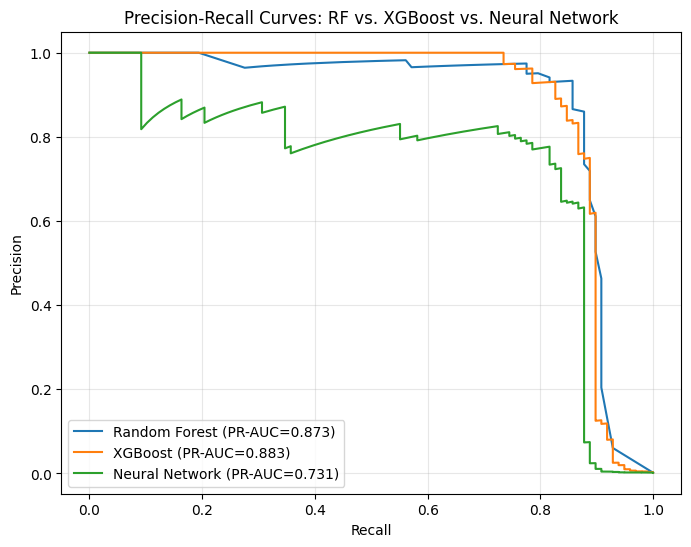

Random Forest: PR-AUC = 0.8734
XGBoost: PR-AUC = 0.8829
Neural Network: PR-AUC = 0.7310


In [2]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
pr_auc_scores = {}

for name, probs in models_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)
    pr_auc_scores[name] = pr_auc
    plt.plot(recall, precision, label=f"{name} (PR-AUC={pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves: RF vs. XGBoost vs. Neural Network")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for name, score in pr_auc_scores.items():
    print(f"{name}: PR-AUC = {score:.4f}")

## 3. F1-Optimal Comparison

Same threshold-selection method applied to every model: maximize F1 across the full precision-recall curve.

In [3]:
from sklearn.metrics import confusion_matrix, classification_report

def f1_optimal(y_true, probs):
    precision, recall, thresholds = precision_recall_curve(y_true, probs)
    f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], precision[best_idx], recall[best_idx], f1_scores[best_idx]

print(f"{'Model':<16} {'Threshold':>10} {'Precision':>10} {'Recall':>8} {'F1':>8}")
for name, probs in models_probs.items():
    t, p, r, f1 = f1_optimal(y_test, probs)
    print(f"{name:<16} {t:>10.4f} {p:>10.4f} {r:>8.4f} {f1:>8.4f}")

Model             Threshold  Precision   Recall       F1
Random Forest        0.4100     0.9333   0.8571   0.8936
XGBoost              0.9374     0.9310   0.8265   0.8757
Neural Network       0.2872     0.7767   0.8163   0.7960


## 4. Cost-Optimal Comparison

Same cost framework applied to every model: minimize `sum(missed fraud Amount) + REVIEW_COST * false_positives`.

In [4]:
REVIEW_COST = 10  # same assumption used in every individual model notebook

y_test_arr = y_test.values
amount_arr = amount_test.values

def cost_optimal(y_true_arr, amount_arr, probs, review_cost):
    precision, recall, thresholds = precision_recall_curve(y_test, probs)
    costs = []
    for t in thresholds:
        y_pred_t = (probs >= t).astype(int)
        fn_mask = (y_pred_t == 0) & (y_true_arr == 1)
        fp_mask = (y_pred_t == 1) & (y_true_arr == 0)
        cost = amount_arr[fn_mask].sum() + review_cost * fp_mask.sum()
        costs.append(cost)
    costs = np.array(costs)
    best_idx = np.argmin(costs)
    return thresholds[best_idx], precision[best_idx], recall[best_idx], costs[best_idx]

print(f"{'Model':<16} {'Threshold':>10} {'Precision':>10} {'Recall':>8} {'Total Cost':>12}")
cost_results = {}
for name, probs in models_probs.items():
    t, p, r, cost = cost_optimal(y_test_arr, amount_arr, probs, REVIEW_COST)
    cost_results[name] = cost
    print(f"{name:<16} {t:>10.4f} {p:>10.4f} {r:>8.4f} {'$' + format(cost, ',.2f'):>12}")

Model             Threshold  Precision   Recall   Total Cost
Random Forest        0.3000     0.8600   0.8776    $1,969.72
XGBoost              0.7161     0.8913   0.8367    $2,043.10
Neural Network       0.2872     0.7767   0.8163    $2,105.41


## 5. Confusion Matrices at Each Model's Cost-Optimal Threshold

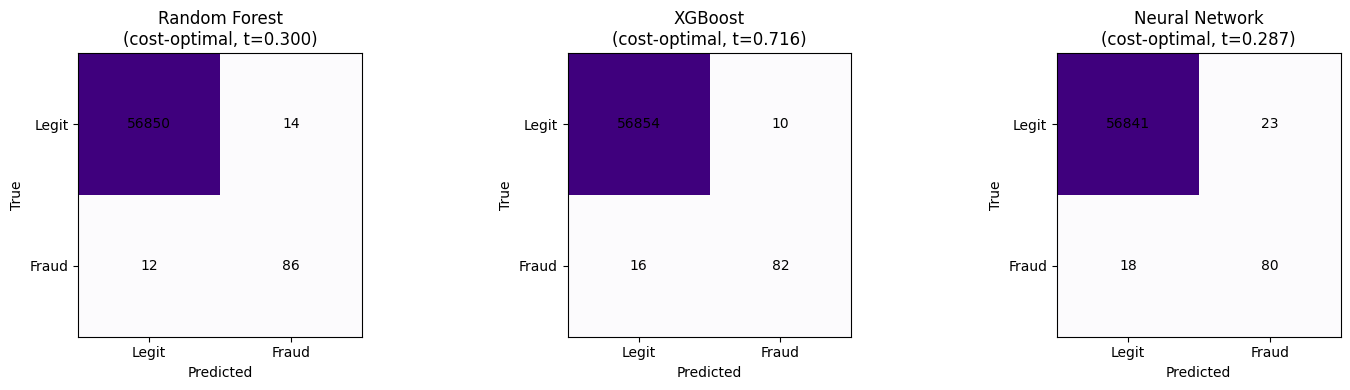

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, probs) in zip(axes, models_probs.items()):
    t, _, _, _ = cost_optimal(y_test_arr, amount_arr, probs, REVIEW_COST)
    y_pred = (probs >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    ax.imshow(cm, cmap='Purples')
    ax.set_title(f"{name}\n(cost-optimal, t={t:.3f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Legit', 'Fraud'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Legit', 'Fraud'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

## 6. Verdict

**Random Forest wins clearly** at the operating point that actually matters (cost-optimal threshold) — despite XGBoost's marginally higher raw PR-AUC.

| | PR-AUC | Cost-optimal total cost |
|---|---|---|
| **Random Forest** | 0.8734 | **$1,969.72** |
| XGBoost | 0.8829 | $2,043.10 |
| Neural Network (focal loss) | ~0.73 (varies by run) | ~$2,100-2,180 |

RF beats XGBoost by about $73 in total cost, despite XGBoost having a slightly higher PR-AUC (0.883 vs. 0.873) — another reminder that the aggregate curve-summary metric doesn't always predict which model wins at the specific point you'd actually deploy. RF is also simpler to get here: plain defaults already beat two independent tuning attempts for both RF and XGBoost, so no hyperparameter search was needed for either model's final result. The Neural Network isn't competitive: PCA-compressed features and a very small, hard-to-separate positive class favor tree ensembles that can carve out decision boundaries directly, over a network that has to learn that structure from very few positive examples (see `04_neural_network_experiment.ipynb` for the full investigation of why).

**Recommendation: deploy Random Forest at its cost-optimal threshold (~0.30, review-cost assumption $10/false-positive).**